In [1]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
import matplotlib.pyplot as plt
np.random.seed(42)

In [2]:
def generate_2d_clouds(N=400):
    cloud1 = np.random.normal([2, 2], [0.5, 1], (N, 2))
    cloud2 = np.random.normal([-6, -2], [3, 1], (N, 2))
    cloud3 = np.random.uniform(low=[-10, 1], high=[-4, 7], size=(N, 2))
    return cloud1, cloud2, cloud3

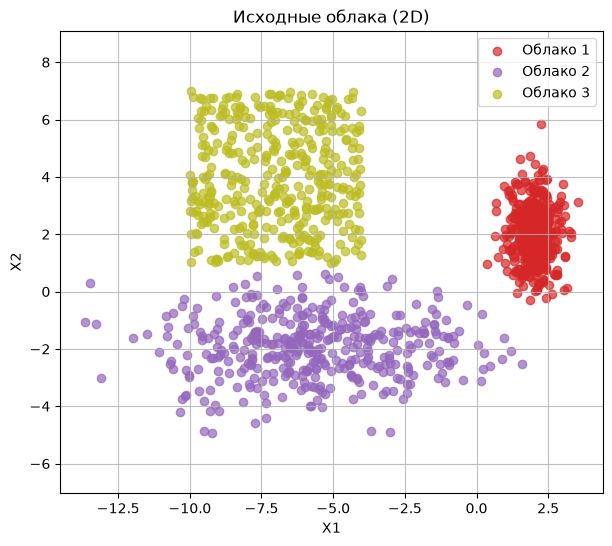

In [3]:
def visualize_2d_clouds(cloud1, cloud2, cloud3):
    plt.figure(figsize=(7, 6))
    plt.scatter(cloud1[:, 0], cloud1[:, 1], c='#d62728', alpha=0.7, label='Облако 1')
    plt.scatter(cloud2[:, 0], cloud2[:, 1], c='#9467bd', alpha=0.7, label='Облако 2')
    plt.scatter(cloud3[:, 0], cloud3[:, 1], c='#bcbd22', alpha=0.7, label='Облако 3')
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.title('Исходные облака (2D)')
    plt.legend()
    plt.grid(True, alpha=0.8)
    plt.axis('equal')
    plt.show()

N = 400
cloud1, cloud2, cloud3 = generate_2d_clouds(N)
visualize_2d_clouds(cloud1, cloud2, cloud3)

In [4]:
def extend_to_5d(cloud_2d):
    x1 = cloud_2d[:, 0]
    x2 = cloud_2d[:, 1]
    x3 = x1 + x2
    x4 = np.log(np.abs(x1) + 1) + x2
    x5 = np.sin(x1 * x2)
    cloud_5d = np.column_stack([x1, x2, x3, x4, x5])
    return cloud_5d

cloud1_5d = extend_to_5d(cloud1)
cloud2_5d = extend_to_5d(cloud2)
cloud3_5d = extend_to_5d(cloud3)

In [5]:
def pca_clouds(cloud1_5d, cloud2_5d, cloud3_5d):
    all_clouds_5d = np.vstack([cloud1_5d, cloud2_5d, cloud3_5d])
    pca = PCA(n_components = 2,random_state=42)
    all_clouds_pca = pca.fit_transform(all_clouds_5d)

    n1, n2 = len(cloud1_5d), len(cloud2_5d)
    cloud1_pca = all_clouds_pca[:n1]
    cloud2_pca = all_clouds_pca[n1:n1 + n2]
    cloud3_pca = all_clouds_pca[n1 + n2:]
    return cloud1_pca, cloud2_pca, cloud3_pca, pca

cloud1_pca, cloud2_pca, cloud3_pca, pca = pca_clouds(cloud1_5d, cloud2_5d, cloud3_5d)

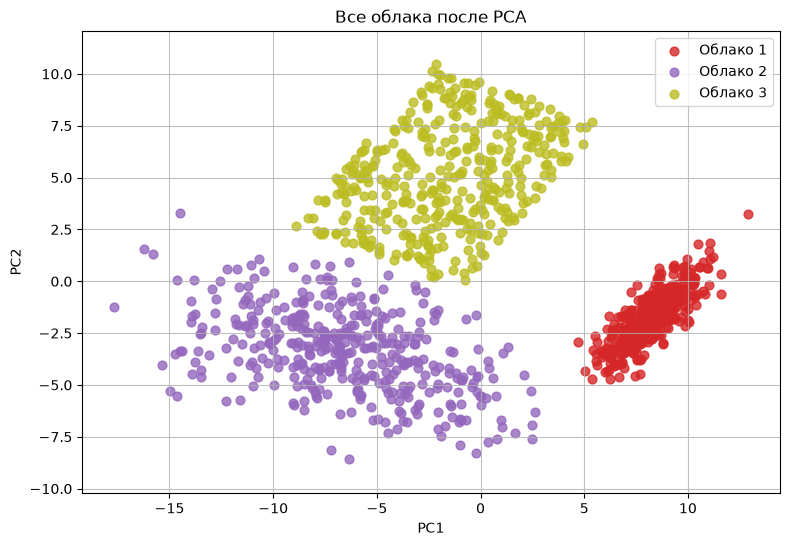

In [6]:
def visualize_all_pca(cloud1, cloud2, cloud3):
    plt.figure(figsize=(9, 6))
    plt.scatter(cloud1[:, 0], cloud1[:, 1], c='#d62728', alpha=0.8, s=40, label='Облако 1')
    plt.scatter(cloud2[:, 0], cloud2[:, 1], c='#9467bd', alpha=0.8, s=40, label='Облако 2')
    plt.scatter(cloud3[:, 0], cloud3[:, 1], c='#bcbd22', alpha=0.8, s=40, label='Облако 3')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.title('Все облака после PCA')
    plt.legend()
    plt.grid(True, alpha=0.8)
    plt.axis('equal')
    plt.show()

visualize_all_pca(cloud1_pca, cloud2_pca, cloud3_pca)

In [7]:
def visualize_clustering(points, labels, model):
    plt.figure(figsize=(9, 7))
    scatter = plt.scatter(points[:, 0], points[:, 1], c=labels, alpha=0.6, cmap='viridis')
    centroids = model.cluster_centers_
    plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='X', label='Центры кластеров')
    plt.colorbar(scatter)
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.title("K-means кластеризация (K=3)")
    plt.grid(True, alpha=0.8)
    plt.axis('equal')
    plt.show()

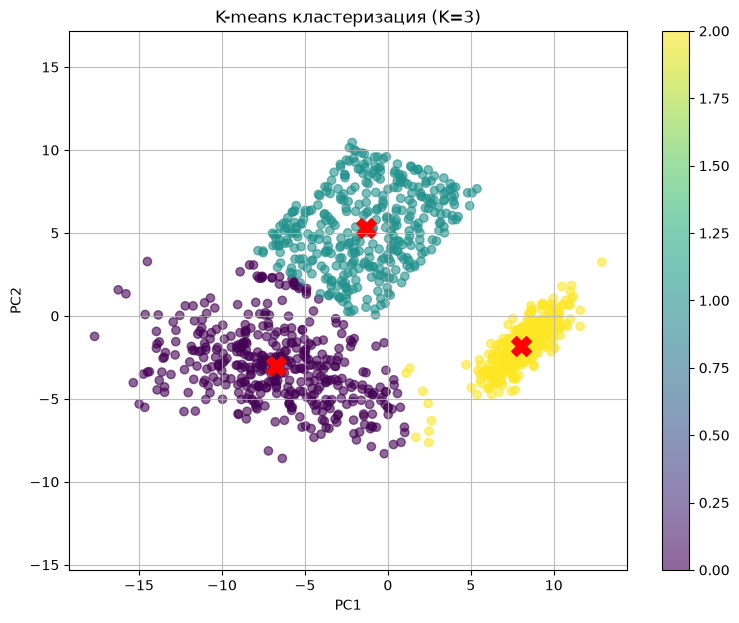

In [8]:
data = np.vstack([cloud1_pca, cloud2_pca, cloud3_pca])
kmeans_optimal = KMeans(n_clusters=3,n_init='auto', random_state=42)
labels_optimal = kmeans_optimal.fit_predict(data)
visualize_clustering(data, labels_optimal, kmeans_optimal)

In [9]:
k = 7
silhouette_scores = [0] * (k + 1)

for i in range(2, k + 1):
    kmeans = KMeans(n_clusters=i,n_init='auto', random_state=42)
    predicted = kmeans.fit_predict(data)

    silhouette_scores[i] = silhouette_score(data, predicted)

    print(f"k = {i}: среднее = {silhouette_scores[i]:.3f}")

k = 2: среднее = 0.523
k = 3: среднее = 0.595
k = 4: среднее = 0.561
k = 5: среднее = 0.546
k = 6: среднее = 0.531
k = 7: среднее = 0.506


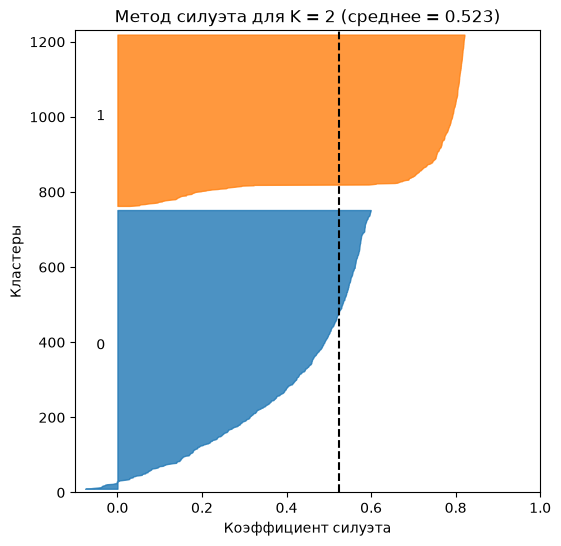

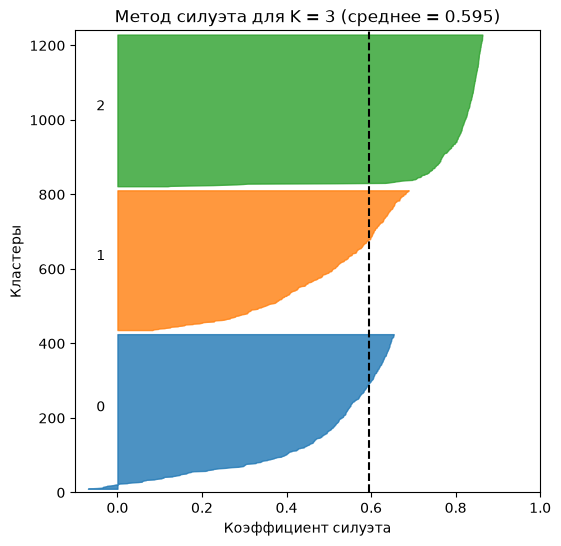

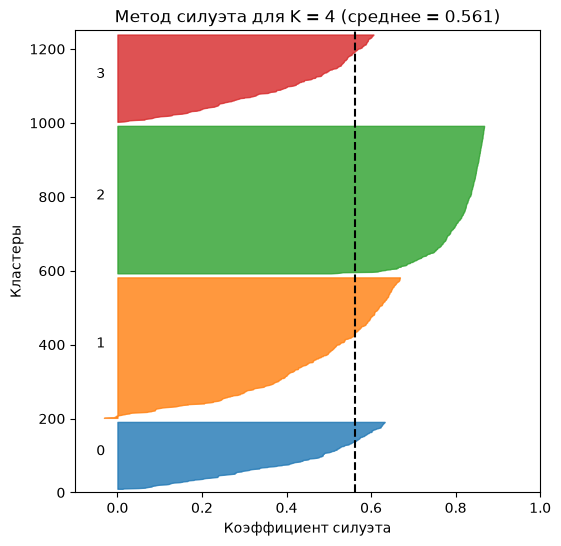

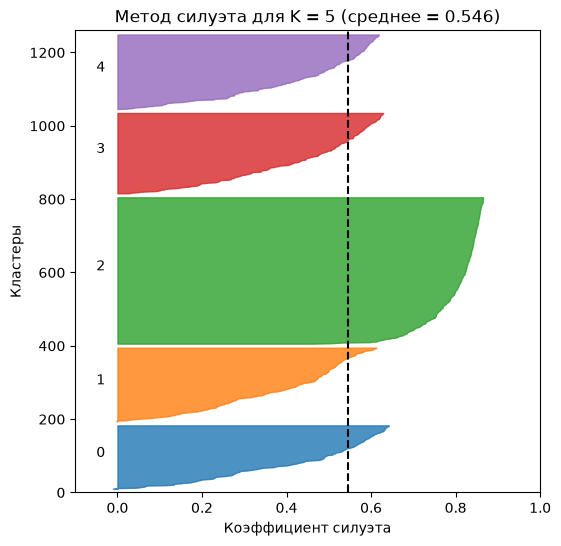

In [10]:
range_n_clusters = [x for x in range(2,6)]
def optimal_k_search(data, range_n_clusters):
    range_n_clusters = range_n_clusters
    silhouette_scores = []

    for n_clusters in range_n_clusters:
        clusterer = KMeans(n_clusters=n_clusters,n_init='auto', random_state=42)
        cluster_labels = clusterer.fit_predict(data)

        silhouette_avg = silhouette_score(data, cluster_labels)
        silhouette_scores.append(silhouette_avg)
        sample_silhouette_values = silhouette_samples(data, cluster_labels)

        fig, ax = plt.subplots(figsize=(6, 6))
        y_lower = 10

        for i in range(n_clusters):
            ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
            ith_cluster_silhouette_values.sort()

            size_cluster_i = ith_cluster_silhouette_values.shape[0]
            y_upper = y_lower + size_cluster_i

            color = plt.cm.tab10(i)
            ax.fill_betweenx(np.arange(y_lower, y_upper),
                             0, ith_cluster_silhouette_values,
                             facecolor=color, edgecolor=color, alpha=0.8)

            ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
            y_lower = y_upper + 10

        ax.axvline(x=silhouette_avg, color="black", linestyle="--")
        ax.set_xlim([-0.1, 1])
        ax.set_ylim([0, len(data) + (n_clusters + 1) * 10])
        ax.set_xlabel("Коэффициент силуэта")
        ax.set_ylabel("Кластеры")
        ax.set_title(f"Метод силуэта для K = {n_clusters} (среднее = {silhouette_avg:.3f})")
        plt.show()
    return range_n_clusters[np.argmax(silhouette_scores)]
optimal_k = optimal_k_search(data, range_n_clusters)

In [11]:
print(f"\nОптимальное K по силуэту: {optimal_k}")


Оптимальное K по силуэту: 3
